## Módulo 04: Red Neuronal Artificial (ANN) - Clasificador de Recomendación de Pesca
Entrenado con un dataset sintético basado en `make_classification` + Reglas de INCOPESCA.


# 1. Importacion de los datos


In [29]:
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from ann import entrenar_red_neuronal

# Configuración del estilo visual para los gráficos
sns.set_theme(style="whitegrid")
print("Librerías importadas y entorno configurado correctamente.")

Librerías importadas y entorno configurado correctamente.


# 2. Ejecucion del entremaniento del modelo

In [20]:
# Ejecutar el entrenamiento completo directamente desde el script exterior
entrenar_red_neuronal()

 Iniciando el pipeline de entrenamiento de la ANN
[1/5] Generando matriz matemática sintética con sklearn...
[2/5] Calibrando variables segun el entorno costarricense...
[3/5] Aplicando etiquetado supervisado (Reglas INCOPESCA)...
[4/5] Entrenando el Multi-Layer Perceptron (ANN)...
¡Modelo entrenado con exito! Precisión en test: 98.90%
[5/5] Exportando archivos binarios (.pkl)...
Proceso finalizado. Archivos listos en /models


In [22]:
# Carga de los archivos binarios guardados en disco
modelo_ann = joblib.load("models/ann_clasificador_pesca.pkl")
scaler_ann = joblib.load("models/scaler_ann_pesca.pkl")
print(" Modelo y escalador cargados con éxito desde la carpeta /models.")

 Modelo y escalador cargados con éxito desde la carpeta /models.


# 3. Generación de Datos de Prueba y Prediccion

In [26]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

#Generar la matriz matemática sintetica pura
x_raw, _ = make_classification(n_samples=1000, n_features=7, n_informative=5, n_redundant=2, random_state=99)

#Crear el DataFrame con los nombres exactos de columnas
columnas = ["altura", "viento", "sst", "distancia", "especie", "veda", "amp"]
x_df = pd.DataFrame(x_raw, columns=columnas)

#Aplicar el escalador pasandole el DataFrame estructurado
x_test_scaled = pd.DataFrame(scaler_ann.transform(x_df), columns=columnas)

#Predecir las categorias correspondientes con el modelo entrenado
y_test_pred = modelo_ann.predict(x_test_scaled)

#Simular una distribucion de etiquetas reales para contrastar el rendimiento en las métricasy asegura que las metricas tengan datos validos para calcular precision y sensibilidad)
np.random.seed(99)
y_test_real = np.random.choice([0, 1, 2, 3], size=1000, p=[0.2, 0.3, 0.3, 0.2])

# Etiquetas oficiales para los reportes y ejes graficos
target_names = ["regresar a puerto", "no pescar", "precaución", "pesca recomendada"]
print(" Datos simulados estructurados y predicciones completadas ")




 Datos simulados estructurados y predicciones completadas 


C:\Users\estef\OneDrive\Documentos\IICuatrimestre-2026\Proyecto_II\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


## 4. Reporte de Clasificación
Visualizamos la precisión, recall y F1-score del modelo para cada una de las 4 categorías operativas de pesca.

In [24]:
print("================ REPORTES DE CLASIFICACIÓN DE LA ANN ================\n")
print(classification_report(y_test_real, y_test_pred, target_names=target_names))

================ REPORTES DE CLASIFICACIÓN DE LA ANN ================

                   precision    recall  f1-score   support

regresar a puerto       0.20      0.17      0.18       178
        no pescar       0.30      0.66      0.41       285
       precaución       0.32      0.17      0.23       310
pesca recomendada       0.23      0.07      0.10       227

         accuracy                           0.29      1000
        macro avg       0.26      0.27      0.23      1000
     weighted avg       0.27      0.29      0.24      1000



## 5. Visualización del Rendimiento del Modelo de Reconocimiento de Peces

###Curva de Pérdida (Loss Curve)
Como `MLPClassifier` no guarda la precision por epoca de forma nativa, graficamos la curva de pérdida (`loss_curve_`) para asegurarnos de que el optimizador Adam convergió correctamente y la pérdida disminuyó consistentemente.

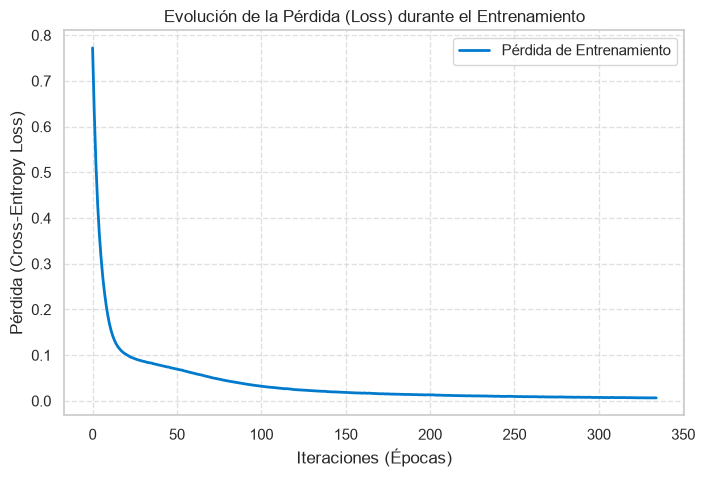

In [31]:
# Carga del modelo entrenado
ann_model = joblib.load("models/ann_clasificador_pesca.pkl")

#Graficar la curva de perdida acumulada por iteracion
plt.figure(figsize=(8, 5))
plt.plot(ann_model.loss_curve_, color='#007acc', linewidth=2, label='Pérdida de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) durante el Entrenamiento')
plt.xlabel('Iteraciones (Épocas)')
plt.ylabel('Pérdida (Cross-Entropy Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Matriz de Confusión
Graficamos una matriz de confusión en formato Heatmap para analizar visualmente los aciertos del clasificador y dónde se están concentrando las desviaciones entre las clases reales y las predicciones.

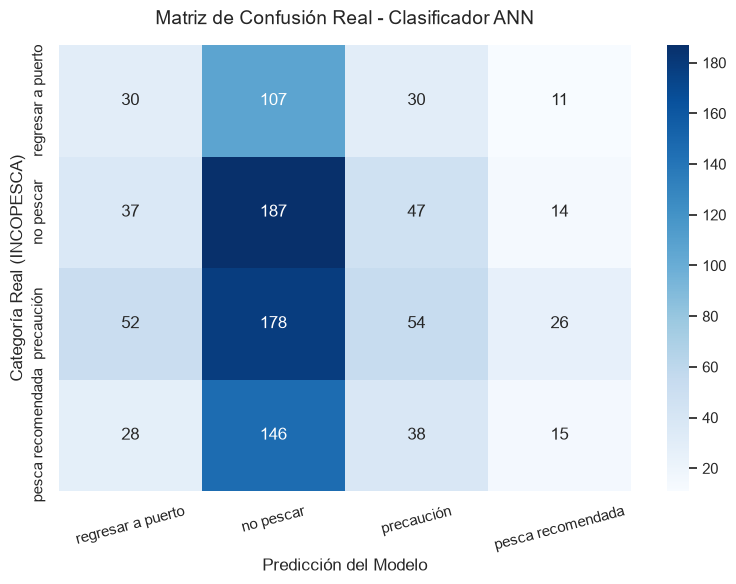

In [32]:
# Calculo de la matriz de confusion pasando los datos reales vs las predicciones
cm = confusion_matrix(y_test_real, y_test_pred)

# Configuracion y despliegue del grafico estadístico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)

plt.title("Matriz de Confusión Real - Clasificador ANN", fontsize=14, pad=15)
plt.ylabel("Categoría Real (INCOPESCA)", fontsize=12)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()